# **Klasifikasi Kualitas Anggur (Wine Quality Classification)**
## *UTS Machine Learning — Prediksi Kualitas Anggur Merah & Putih*

---

| Identitas | |
|-----------|--|
| **Nama** | Alfian Adi Pratama |
| **NIM** | 2304010008 |
| **Prodi** | D3 Statistika Terapan dan Komputasi |
| **Mata Kuliah** | Machine Learning |
| **Semester** | Genap / 2026 |
| **Pengampu** | Dr. Iqbal Kharisudin, M.Sc dan Nur Achmey Selgi Harwanti, S.Stat. M.Stat |

---

### 📋 Deskripsi Dataset
Dataset **Wine Quality** berisi data kimiawi dari sampel anggur merah dan putih. Setiap sampel memiliki 11 variabel kimiawi yang diukur di laboratorium, serta penilaian kualitas dari para ahli.

**Tujuan:** Melakukan **Klasifikasi** untuk memprediksi nilai kualitas anggur (`quality`: skala 0–10) berdasarkan fitur-fitur kimiawi yang tersedia, menggunakan algoritma machine learning yang sesuai.

### 🗂️ Deskripsi Variabel
| Variabel | Tipe | Keterangan |
|----------|------|------------|
| `fixed acidity` | Numerik | Kandungan asam tetap (g/dm³) |
| `volatile acidity` | Numerik | Kandungan asam volatil (g/dm³) |
| `citric acid` | Numerik | Kandungan asam sitrat (g/dm³) |
| `residual sugar` | Numerik | Sisa gula setelah fermentasi (g/dm³) |
| `chlorides` | Numerik | Kandungan klorida (g/dm³) |
| `free sulfur dioxide` | Numerik | SO₂ bebas (mg/dm³) |
| `total sulfur dioxide` | Numerik | Total SO₂ (mg/dm³) |
| `density` | Numerik | Densitas anggur (g/cm³) |
| `pH` | Numerik | Tingkat keasaman |
| `sulphates` | Numerik | Kandungan sulfat (g/dm³) |
| `alcohol` | Numerik | Kadar alkohol (% volume) |
| `quality` | Target | Kualitas anggur (skala 0–10) |
| `Id` | ID | Identifikasi unik setiap sampel |

### 🗂️ Alur Notebook
| No | Tahap | Fokus |
|----|-------|-------|
| 1 | **Import Library** | Setup environment dan library yang dibutuhkan |
| 2 | **Load Data** | Membaca dataset training dan testing |
| 3 | **Pengecekan Data** | Missing values, duplikasi, dan statistik deskriptif |
| 4 | **EDA** | Eksplorasi dan visualisasi data |
| 5 | **Preprocessing** | Feature scaling dan persiapan data modeling |
| 6 | **Modeling** | Pembuatan dan evaluasi model klasifikasi |
| 7 | **Prediksi** | Deployment model pada data testing |
| 8 | **Simpan Hasil** | Export hasil prediksi ke CSV |

---

## **1. Import Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## **2. Load Data**

Terdapat dua dataset yang digunakan:
- **data_training.csv** → dataset berlabel yang digunakan untuk melatih model
- **data_testing.csv** → dataset tanpa label yang akan diprediksi kualitasnya

In [2]:
# Load dataset training dan testing
df_train = pd.read_csv('data_training.csv')
df_test  = pd.read_csv('data_testing.csv')

print(f'Ukuran data training : {df_train.shape[0]} baris × {df_train.shape[1]} kolom')
print(f'Ukuran data testing  : {df_test.shape[0]} baris × {df_test.shape[1]} kolom')

Ukuran data training : 857 baris × 13 kolom
Ukuran data testing  : 286 baris × 12 kolom


In [3]:
print('Preview Data Training:')
df_train.head()

Preview Data Training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3000,0.7400,0.0800,1.7000,0.0940,10.0000,45.0000,0.9958,3.2400,0.5000,9.8000,5,1366
1,8.1000,0.5750,0.2200,2.1000,0.0770,12.0000,65.0000,0.9967,3.2900,0.5100,9.2000,5,103
2,10.1000,0.4300,0.4000,2.6000,0.0920,13.0000,52.0000,0.9983,3.2200,0.6400,10.0000,7,942
3,12.9000,0.5000,0.5500,2.8000,0.0720,7.0000,24.0000,1.0001,3.0900,0.6800,10.9000,6,811
4,8.4000,0.3600,0.3200,2.2000,0.0810,32.0000,79.0000,0.9964,3.3000,0.7200,11.0000,6,918


In [4]:
print('Preview Data Testing:')
df_test.head()

Preview Data Testing:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8000,0.6100,0.0400,1.5000,0.0570,5.0000,10.0000,0.9952,3.4200,0.6000,9.5000,222
1,6.9000,0.8400,0.2100,4.1000,0.0740,16.0000,65.0000,0.9984,3.5300,0.7200,9.2333,1514
2,7.0000,0.5800,0.1200,1.9000,0.0910,34.0000,124.0000,0.9956,3.4400,0.4800,10.5000,417
3,7.8000,0.4800,0.6800,1.7000,0.4150,14.0000,32.0000,0.9966,3.0900,1.0600,9.1000,754
4,12.5000,0.6000,0.4900,4.3000,0.1000,5.0000,14.0000,1.0010,3.2500,0.7400,11.9000,516


## **3. Pengecekan Data**

- Tipe data setiap kolom
- Keberadaan *missing values*
- Keberadaan data duplikat
- Statistik deskriptif

In [5]:
# Informasi umum data training
print('=== INFO DATA TRAINING ===')
df_train.info()

=== INFO DATA TRAINING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [6]:
# Pengecekan missing values — Training
missing_train = df_train.isnull().sum()
print('Missing Values — Data Training:')
print(missing_train[missing_train >= 0].to_frame('Jumlah Missing').assign(
    Persentase=lambda x: (x['Jumlah Missing'] / len(df_train) * 100).round(2).astype(str) + '%'
))

Missing Values — Data Training:
                      Jumlah Missing Persentase
fixed acidity                      0       0.0%
volatile acidity                   0       0.0%
citric acid                        0       0.0%
residual sugar                     0       0.0%
chlorides                          0       0.0%
free sulfur dioxide                0       0.0%
total sulfur dioxide               0       0.0%
density                            0       0.0%
pH                                 0       0.0%
sulphates                          0       0.0%
alcohol                            0       0.0%
quality                            0       0.0%
Id                                 0       0.0%


In [7]:
# Pengecekan missing values — Testing
missing_test = df_test.isnull().sum()
print('Missing Values — Data Testing:')
print(missing_test[missing_test >= 0].to_frame('Jumlah Missing').assign(
    Persentase=lambda x: (x['Jumlah Missing'] / len(df_test) * 100).round(2).astype(str) + '%'
))

Missing Values — Data Testing:
                      Jumlah Missing Persentase
fixed acidity                      0       0.0%
volatile acidity                   0       0.0%
citric acid                        0       0.0%
residual sugar                     0       0.0%
chlorides                          0       0.0%
free sulfur dioxide                0       0.0%
total sulfur dioxide               0       0.0%
density                            0       0.0%
pH                                 0       0.0%
sulphates                          0       0.0%
alcohol                            0       0.0%
Id                                 0       0.0%


In [8]:
# Pengecekan duplikasi data
dup_train = df_train.duplicated().sum()
dup_test  = df_test.duplicated().sum()

print(f'Jumlah baris duplikat — Training : {dup_train}')
print(f'Jumlah baris duplikat — Testing  : {dup_test}')

Jumlah baris duplikat — Training : 0
Jumlah baris duplikat — Testing  : 0


In [9]:
# Statistik deskriptif data training
print('Statistik Deskriptif — Data Training:')
df_train.describe().T

Statistik Deskriptif — Data Training:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0000,8.2620,1.7020,4.6000,7.1000,7.9000,9.1000,15.6000
volatile acidity,857.0000,0.5294,0.1792,0.1200,0.3950,0.5200,0.6400,1.5800
citric acid,857.0000,0.2674,0.1951,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,857.0000,2.5062,1.2935,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,857.0000,0.0868,0.0487,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,857.0000,15.7830,10.3004,1.0000,7.0000,14.0000,21.0000,68.0000
total sulfur dioxide,857.0000,45.9784,31.6921,6.0000,21.0000,38.0000,63.0000,278.0000
density,857.0000,0.9967,0.0019,0.9901,0.9955,0.9967,0.9978,1.0032
pH,857.0000,3.3131,0.1521,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,857.0000,0.6567,0.1674,0.3900,0.5500,0.6200,0.7300,2.0000


In [10]:
# Distribusi variabel target (quality)
print('Distribusi Variabel Target (quality):')
quality_dist = df_train['quality'].value_counts().sort_index()
print(quality_dist)
print(f'\nKelas yang tersedia: {sorted(df_train["quality"].unique())}')

Distribusi Variabel Target (quality):
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Kelas yang tersedia: [3, 4, 5, 6, 7, 8]


## **4. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk memahami karakteristik data sebelum membangun model. Analisis yang dilakukan meliputi:
1. **Distribusi target** `quality` — melihat ketidakseimbangan kelas
2. **Distribusi setiap fitur** — deteksi skewness dan outlier
3. **Korelasi fitur dengan target** — menentukan fitur paling berpengaruh
4. **Heatmap korelasi antar fitur** — deteksi multikolinearitas
5. **Boxplot fitur per kelas quality** — melihat perbedaan distribusi antar kelas
6. **Deteksi outlier** — identifikasi data ekstrem dengan metode IQR

### 4.1 Distribusi Variabel Target (`quality`)

Melihat distribusi kelas target

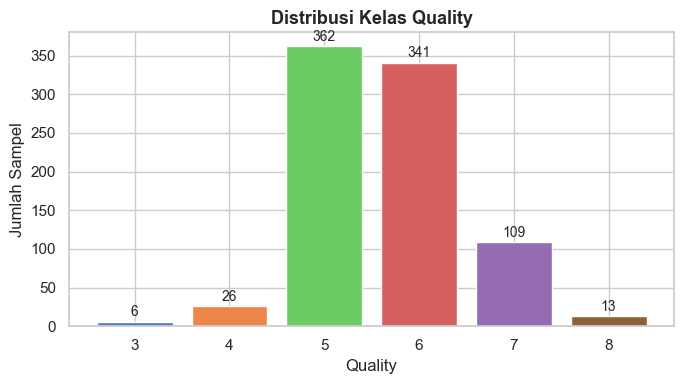


Ringkasan distribusi kelas:
         Jumlah  Persentase (%)
quality                        
3             6          0.7000
4            26          3.0300
5           362         42.2400
6           341         39.7900
7           109         12.7200
8            13          1.5200


In [11]:
quality_counts = df_train['quality'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(quality_counts.index, quality_counts.values,
              color=sns.color_palette('muted', len(quality_counts)), edgecolor='white')
ax.set_title('Distribusi Kelas Quality', fontsize=13, fontweight='bold')
ax.set_xlabel('Quality')
ax.set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, quality_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('\nRingkasan distribusi kelas:')
dist_df = quality_counts.to_frame('Jumlah')
dist_df['Persentase (%)'] = (dist_df['Jumlah'] / dist_df['Jumlah'].sum() * 100).round(2)
print(dist_df)

> **Interpretasi:**
> Distribusi kelas `quality` menunjukkan ketidakseimbangan yang cukup mencolok.
> Kelas **5** (362 sampel, 42.2%) dan **6** (341 sampel, 39.8%) mendominasi dataset — lebih dari **82%** data hanya berasal dari dua kelas ini.
> Sementara itu, kelas ekstrem seperti **3** (6 sampel) dan **8** (13 sampel) sangat jarang ditemui, sehingga model akan kesulitan mempelajari pola pada kelas-kelas tersebut.
> 
> **Implikasi:** Kondisi ini perlu ditangani saat pemodelan, salah satunya dengan menggunakan parameter `class_weight='balanced'` agar model tidak terlalu condong memprediksi kelas mayoritas, serta menggunakan `stratify=y` saat membagi data.

### 4.2 Distribusi Setiap Fitur

Histogram dan KDE plot untuk setiap fitur membantu mendeteksi *skewness* (kemiringan distribusi) dan potensi outlier.

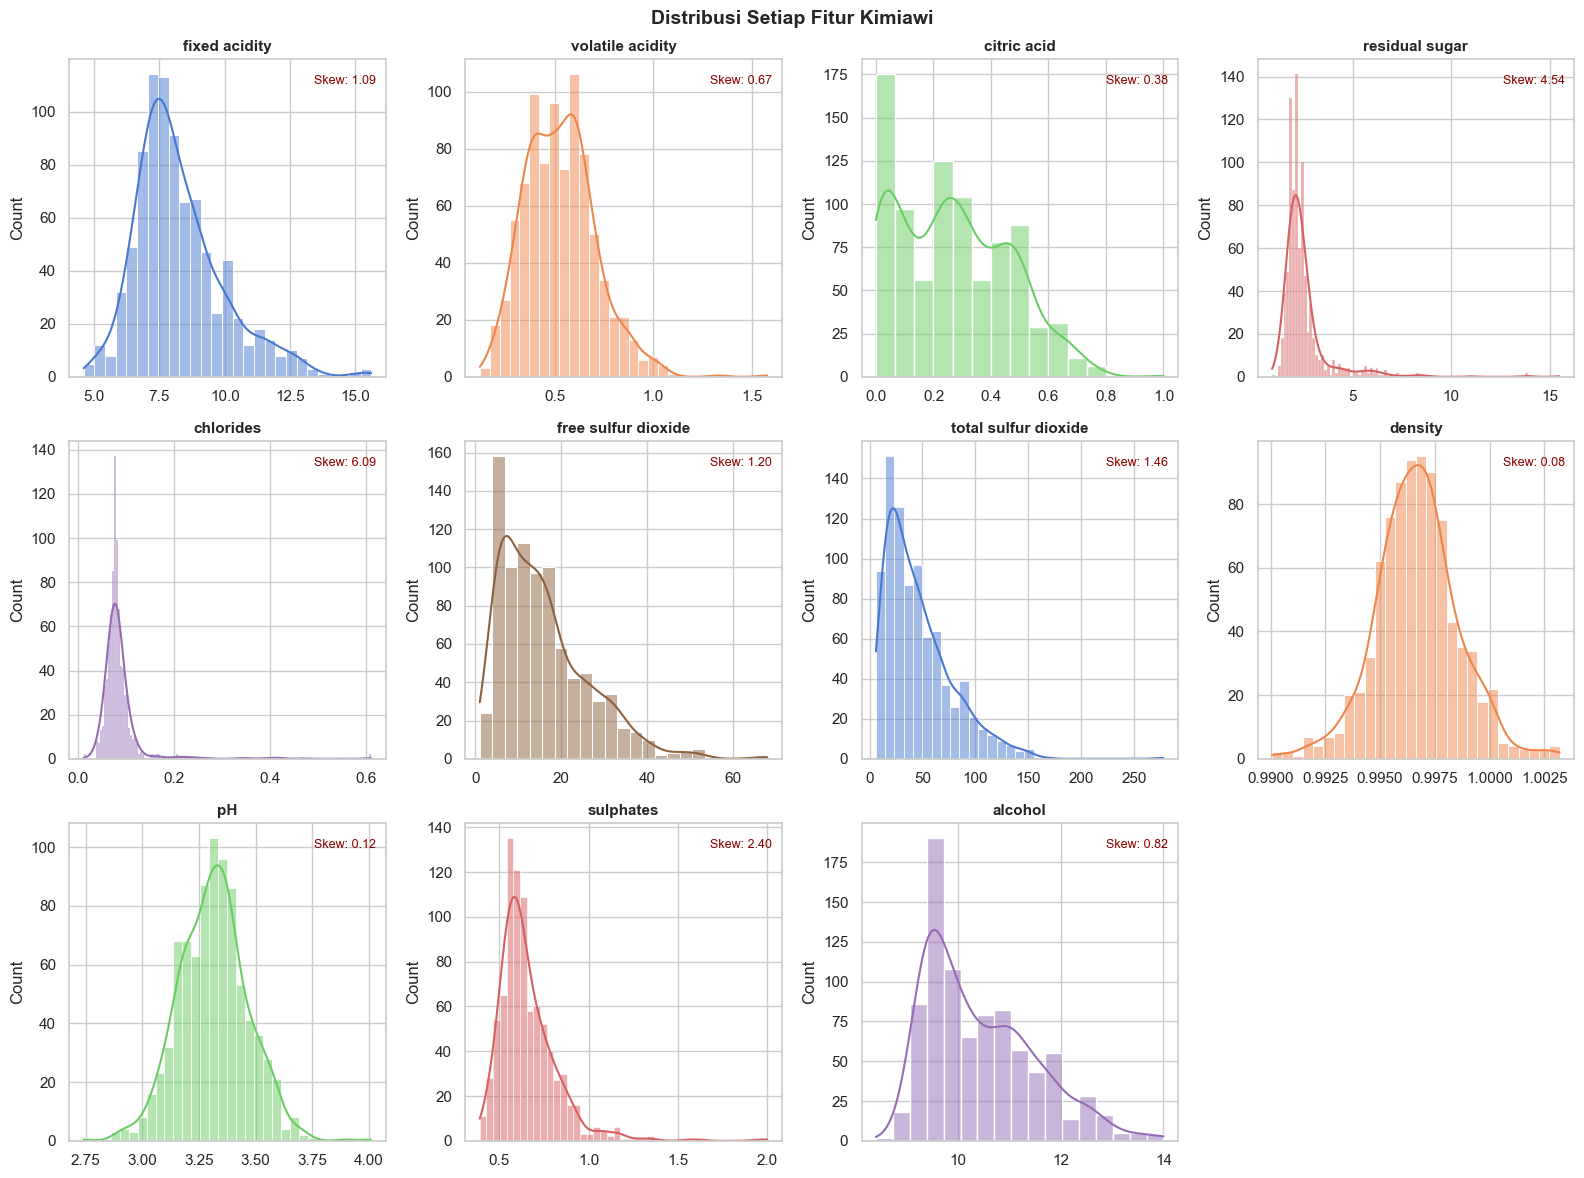


Nilai Skewness setiap fitur:
                      Skewness       Kategori
chlorides               6.0903  Highly Skewed
residual sugar          4.5359  Highly Skewed
sulphates               2.4022  Highly Skewed
total sulfur dioxide    1.4632  Highly Skewed
free sulfur dioxide     1.2041  Highly Skewed
fixed acidity           1.0904  Highly Skewed
alcohol                 0.8228       Moderate
volatile acidity        0.6703       Moderate
citric acid             0.3824         Normal
pH                      0.1156         Normal
density                 0.0834         Normal


In [12]:
features = [c for c in df_train.columns if c not in ['quality', 'Id']]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(df_train[feat], kde=True, ax=axes[i], color=sns.color_palette('muted')[i % 6])
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    skew_val = df_train[feat].skew()
    axes[i].text(0.97, 0.95, f'Skew: {skew_val:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='darkred')

# Hide last unused subplot
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur Kimiawi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNilai Skewness setiap fitur:')
skew_df = df_train[features].skew().to_frame('Skewness').sort_values('Skewness', ascending=False)
skew_df['Kategori'] = skew_df['Skewness'].apply(
    lambda x: 'Highly Skewed' if abs(x) > 1 else ('Moderate' if abs(x) > 0.5 else 'Normal')
)
print(skew_df)

> **Interpretasi:**
> Sebagian besar fitur tidak terdistribusi secara simetris. Yang paling mencolok:
> - `chlorides` (skew = **6.09**) dan `residual sugar` (skew = **4.54**) — keduanya sangat skewed ke kanan, menandakan adanya sampel dengan nilai jauh di atas rata-rata.
> - `sulphates` (skew = **2.40**), `total sulfur dioxide` (skew = **1.46**), dan `free sulfur dioxide` (skew = **1.20**) — moderately skewed.
> - `density` (skew = **0.08**) dan `pH` (skew = **0.12**) — paling mendekati distribusi normal.
> 
> **Implikasi:** Fitur-fitur dengan skewness tinggi perlu di-scaling sebelum masuk ke model yang sensitif terhadap perbedaan skala seperti Logistic Regression dan SVM.

### 4.3 Korelasi Fitur dengan Target (`quality`)

Korelasi Pearson antara setiap fitur dan variabel target menunjukkan seberapa kuat hubungan linear antara fitur dan kualitas anggur. Fitur dengan korelasi tinggi (positif atau negatif) cenderung lebih informatif untuk model.

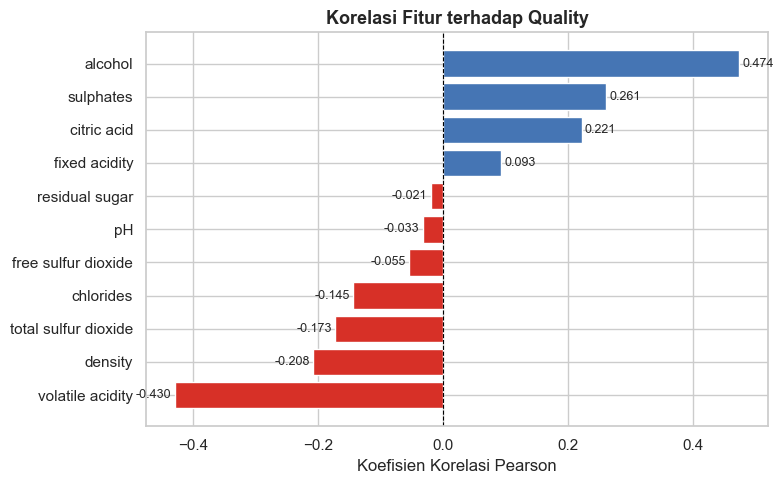

In [13]:
corr_target = df_train[features + ['quality']].corr()['quality'].drop('quality').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Korelasi Fitur terhadap Quality', fontsize=13, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson')
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

> **Interpretasi:**
> Dua fitur dengan pengaruh terkuat terhadap `quality`:
> - **`alcohol`** (r = **+0.474**): semakin tinggi kadar alkohol, kualitas anggur cenderung lebih baik — ini juga dikonfirmasi oleh analisis rata-rata quality per kuartil.
> - **`volatile acidity`** (r = **−0.430**): kadar asam volatil yang tinggi menghasilkan rasa asam yang mengganggu, sehingga menurunkan penilaian kualitas.
> 
> Beberapa fitur seperti `residual sugar` (r = −0.021) dan `pH` (r = −0.033) memiliki korelasi linear yang sangat lemah. Meski begitu, keduanya tetap dipertahankan karena model tree-based mampu menangkap hubungan non-linear yang tidak terlihat dari korelasi sederhana.

### 4.4 Heatmap Korelasi Antar Fitur

Heatmap korelasi memvisualisasikan hubungan antar semua fitur sekaligus. Korelasi tinggi antar fitur (*multikolinearitas*) dapat mengindikasikan fitur yang redundan dan berpotensi menurunkan performa beberapa algoritma.

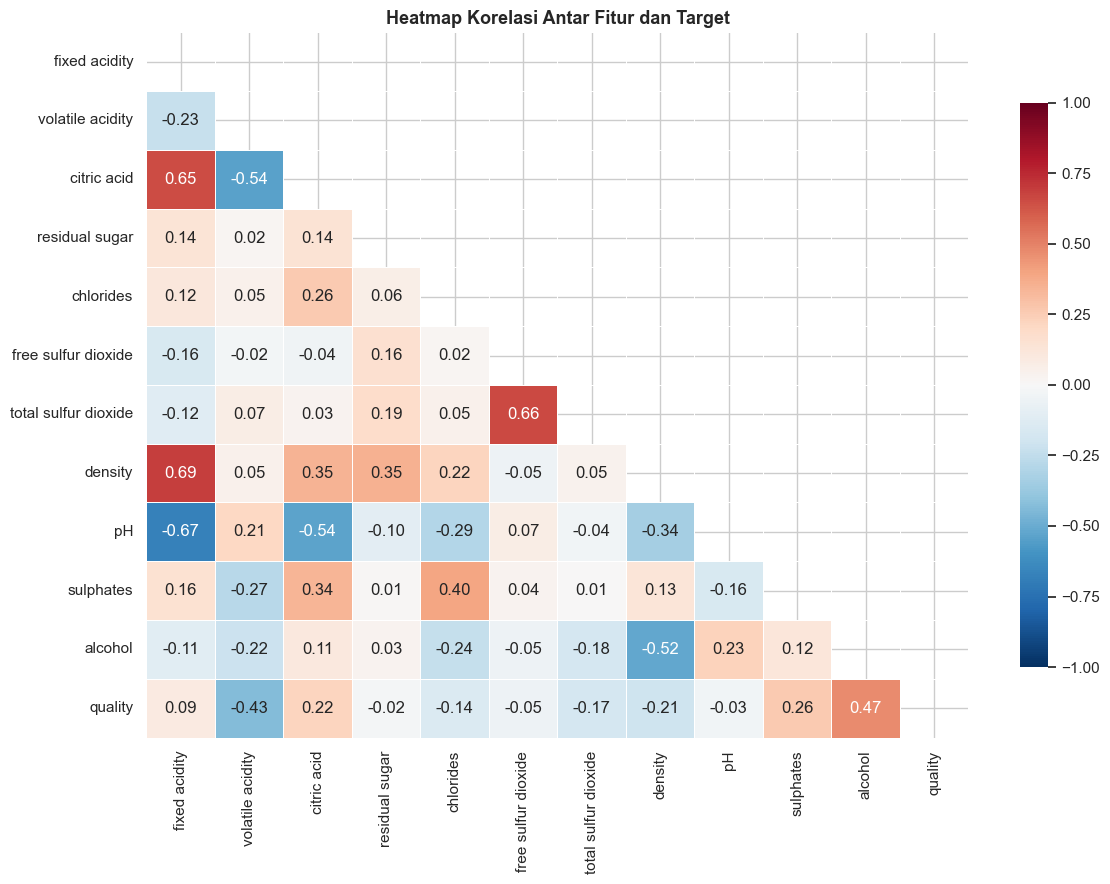


Pasangan fitur dengan korelasi tinggi (|r| > 0.6, ekskl. diagonal):
  citric acid ↔ fixed acidity: +0.654
  total sulfur dioxide ↔ free sulfur dioxide: +0.659
  density ↔ fixed acidity: +0.688
  pH ↔ fixed acidity: -0.674


In [14]:
corr_matrix = df_train[features + ['quality']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap Korelasi Antar Fitur dan Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight multikolinearitas tinggi
print('\nPasangan fitur dengan korelasi tinggi (|r| > 0.6, ekskl. diagonal):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))
if high_corr:
    for f1, f2, r in high_corr:
        print(f'  {f1} ↔ {f2}: {r:+.3f}')
else:
    print('  Tidak ada pasangan fitur dengan multikolinearitas tinggi.')

> **Interpretasi:**
> Terdapat beberapa pasangan fitur dengan korelasi tinggi (|r| > 0.6) yang secara kimia memang masuk akal:
> - `density` ↔ `fixed acidity` (r = **+0.688**): anggur dengan keasaman tetap tinggi cenderung lebih padat.
> - `pH` ↔ `fixed acidity` (r = **−0.674**): semakin tinggi kadar asam, pH-nya semakin rendah.
> - `total sulfur dioxide` ↔ `free sulfur dioxide` (r = **+0.659**): wajar karena free SO₂ adalah bagian dari total SO₂.
> - `citric acid` ↔ `fixed acidity` (r = **+0.654**): asam sitrat merupakan salah satu komponen pembentuk keasaman tetap.
> 
> **Implikasi:** Multikolinearitas seperti ini bisa mengganggu interpretasi koefisien pada model linear. Namun untuk Random Forest dan Gradient Boosting, kondisi ini tidak menjadi masalah yang signifikan.

### 4.5 Boxplot Fitur per Kelas Quality

Boxplot per kelas `quality` memperlihatkan bagaimana distribusi setiap fitur berbeda antar kelas. Fitur yang menunjukkan perbedaan distribusi yang jelas antar kelas adalah fitur yang paling diskriminatif dan berguna untuk klasifikasi.

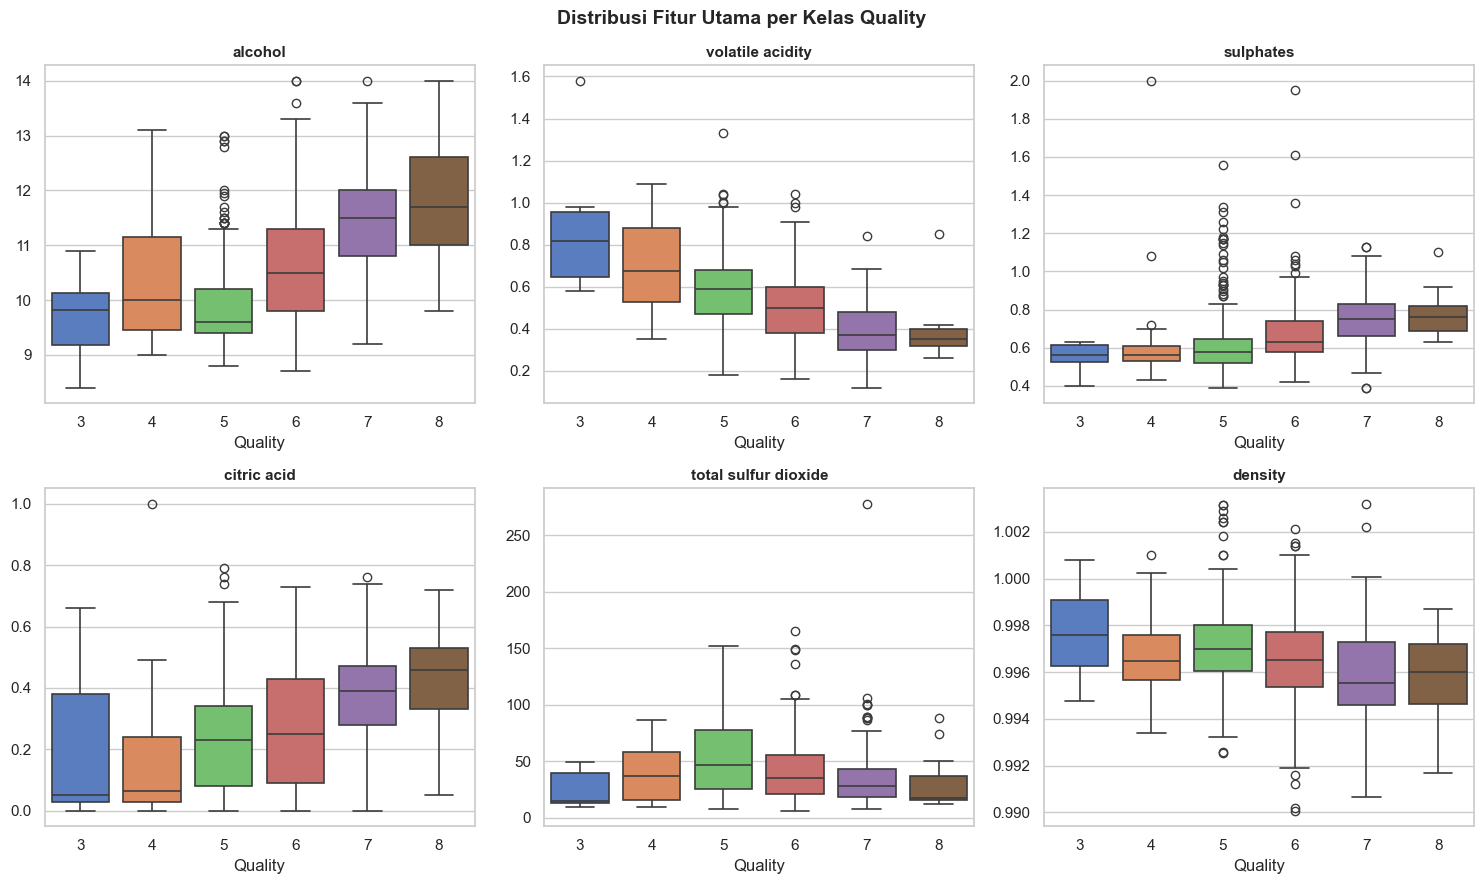

In [15]:
# Fitur paling relevan berdasarkan korelasi
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid',
                'total sulfur dioxide', 'density']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

palette = sns.color_palette('muted', df_train['quality'].nunique())

for i, feat in enumerate(top_features):
    sns.boxplot(
        data=df_train, x='quality', y=feat,
        palette=palette, ax=axes[i], linewidth=1.2
    )
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('')

plt.suptitle('Distribusi Fitur Utama per Kelas Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretasi:**
> Dari keenam fitur yang ditampilkan, `alcohol` dan `volatile acidity` paling mudah dibedakan secara visual antar kelas:
> - **`alcohol`**: tren kenaikan dari kelas 3 ke 8 cukup konsisten — fitur paling diskriminatif secara visual.
> - **`volatile acidity`**: tren penurunan yang jelas — anggur berkualitas rendah (3–4) memiliki volatile acidity yang jauh lebih tinggi.
> - **`sulphates`** dan **`density`**: pola yang searah meski tidak setajam dua fitur utama.
> - **`citric acid`** dan **`total sulfur dioxide`**: distribusinya lebih banyak tumpang tindih, namun tetap membawa sedikit sinyal yang bisa dimanfaatkan model.
> 
> **Kesimpulan:** `alcohol` dan `volatile acidity` adalah dua fitur paling diskriminatif untuk membedakan kelas quality.

### 4.6 Deteksi Outlier (Metode IQR)

Outlier diidentifikasi menggunakan metode **Interquartile Range (IQR)**. Data dianggap outlier jika nilainya berada di luar batas `Q1 − 1.5×IQR` atau `Q3 + 1.5×IQR`.

Ringkasan Outlier per Fitur (Metode IQR):
                      Jumlah Outlier  Persentase (%)  Lower Bound  Upper Bound
Fitur                                                                         
fixed acidity                     30          3.5000       4.1000      12.1000
volatile acidity                   8          0.9300       0.0275       1.0075
citric acid                        1          0.1200      -0.4050       0.9150
residual sugar                    76          8.8700       0.8500       3.6500
chlorides                         59          6.8800       0.0400       0.1200
free sulfur dioxide               15          1.7500     -14.0000      42.0000
total sulfur dioxide              19          2.2200     -42.0000     126.0000
density                           25          2.9200       0.9921       1.0012
pH                                14          1.6300       2.9250       3.6850
sulphates                         31          3.6200       0.2800       1.0000
alcohol   

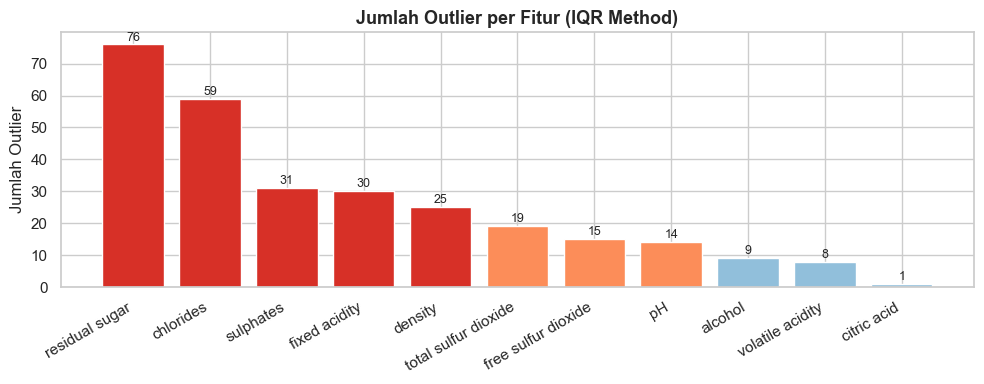

In [16]:
outlier_info = []
for feat in features:
    Q1 = df_train[feat].quantile(0.25)
    Q3 = df_train[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_train[feat] < lower) | (df_train[feat] > upper)).sum()
    outlier_info.append({
        'Fitur': feat, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Jumlah Outlier': n_out,
        'Persentase (%)': round(n_out / len(df_train) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_info).set_index('Fitur')
print('Ringkasan Outlier per Fitur (Metode IQR):')
print(outlier_df[['Jumlah Outlier', 'Persentase (%)', 'Lower Bound', 'Upper Bound']].to_string())

# Visualisasi jumlah outlier
fig, ax = plt.subplots(figsize=(10, 4))
out_vals = outlier_df['Jumlah Outlier'].sort_values(ascending=False)
bars = ax.bar(out_vals.index, out_vals.values,
              color=['#d73027' if v > 20 else '#fc8d59' if v > 10 else '#91bfdb'
                     for v in out_vals.values], edgecolor='white')
ax.set_title('Jumlah Outlier per Fitur (IQR Method)', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Outlier')
ax.set_xticklabels(out_vals.index, rotation=30, ha='right')
for bar, val in zip(bars, out_vals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

> **Interpretasi:**
> Fitur dengan outlier terbanyak adalah **`residual sugar`** (76 sampel, 8.9%) dan **`chlorides`** (59 sampel, 6.9%), konsisten dengan nilai skewness keduanya yang sangat tinggi.
> Nilai-nilai ekstrem ini kemungkinan besar merupakan data valid yang mencerminkan anggur dengan komposisi kimia tidak lazim, bukan kesalahan pengukuran.
> 
> **Keputusan:** Outlier **tidak dihapus** dengan pertimbangan:
> 1. Jumlahnya relatif kecil (< 9% per fitur)
> 2. Algoritma tree-based secara alami robust terhadap outlier
> 3. Menghapus outlier berisiko menghilangkan informasi berharga, terutama dari kelas ekstrem (3 dan 8) yang sampelnya sudah sangat sedikit

### 4.7 Rata-rata Quality per Kelompok Fitur Utama

Analisis ini mengelompokkan fitur `alcohol` dan `volatile acidity` ke dalam kuartil, lalu menghitung rata-rata `quality` di setiap kelompok. Ini membantu mengkonfirmasi hubungan monoton antara fitur dan target.

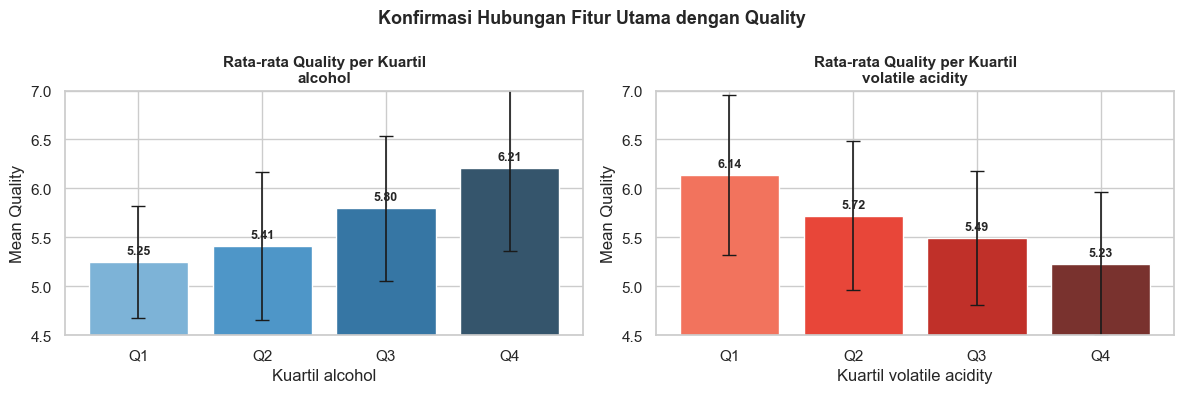

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, asc in zip(axes, ['alcohol', 'volatile acidity'], [True, False]):
    df_train['_grp'] = pd.qcut(df_train[feat], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    grp_mean = df_train.groupby('_grp', observed=True)['quality'].mean()
    grp_std  = df_train.groupby('_grp', observed=True)['quality'].std()

    bars = ax.bar(grp_mean.index, grp_mean.values,
                  yerr=grp_std.values, capsize=5,
                  color=sns.color_palette('Blues_d' if asc else 'Reds_d', 4),
                  edgecolor='white', error_kw={'linewidth': 1.2})
    ax.set_title(f'Rata-rata Quality per Kuartil\n{feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Kuartil {feat}')
    ax.set_ylabel('Mean Quality')
    ax.set_ylim(4.5, 7)
    for bar, val in zip(bars, grp_mean.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

df_train.drop(columns='_grp', inplace=True)
plt.suptitle('Konfirmasi Hubungan Fitur Utama dengan Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretasi:**
> Grafik ini mempertegas pola yang sudah terlihat pada analisis korelasi sebelumnya:
> - **`alcohol`**: rata-rata quality naik secara konsisten dari Q1 (5.25) → Q2 (5.41) → Q3 (5.80) → Q4 (6.21). Selisihnya hampir **1 poin penuh** antara kelompok alkohol terendah dan tertinggi.
> - **`volatile acidity`**: pola sebaliknya — kelompok dengan volatile acidity terendah (Q1) memiliki rata-rata quality tertinggi, dan terus menurun seiring meningkatnya kadar asam volatil.
> 
> Hubungan yang monoton dan konsisten ini mengonfirmasi bahwa kedua fitur layak menjadi acuan utama dalam pembuatan dan interpretasi model.

### 4.8 Violin Plot Distribusi Fitur Utama per Kelas

Violin plot menggabungkan informasi boxplot (median, IQR) dengan estimasi densitas (KDE), sehingga memberikan gambaran distribusi yang lebih lengkap dibanding boxplot biasa — termasuk apakah distribusi bersifat unimodal atau bimodal per kelas.

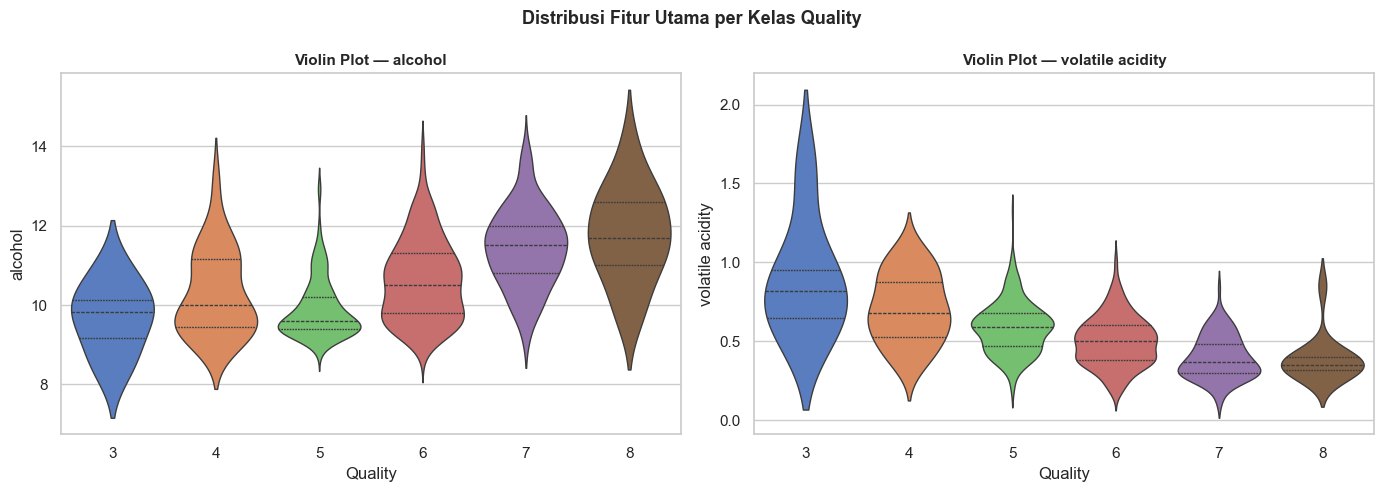

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['alcohol', 'volatile acidity']):
    sns.violinplot(
        data=df_train, x='quality', y=feat,
        palette='muted', ax=ax, inner='quartile', linewidth=1
    )
    ax.set_title(f'Violin Plot — {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Quality')
    ax.set_ylabel(feat)

plt.suptitle('Distribusi Fitur Utama per Kelas Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretasi:**
> Violin plot memberikan gambaran distribusi yang lebih kaya dibanding boxplot biasa, karena menggabungkan informasi sebaran dengan bentuk densitas.
> - **`alcohol`**: kelas 7 dan 8 memiliki distribusi yang lebih sempit dan terkonsentrasi di nilai tinggi, sedangkan kelas 5 dan 6 jauh lebih menyebar — anggur berkualitas tinggi cenderung lebih konsisten dalam kadar alkohol.
> - **`volatile acidity`**: kelas 3–4 distribusinya lebih lebar dengan ekor panjang ke atas, menunjukkan variasi volatile acidity pada anggur berkualitas rendah yang lebih besar.
> 
> Tumpang tindih yang masih terlihat antar kelas menunjukkan bahwa batas antar kelas tidak selalu tegas, dan model perlu cukup kuat untuk menangkap hubungan non-linear di antara fitur-fitur ini.

---
## **5. Preprocessing**

Berdasarkan temuan dari tahap EDA, preprocessing dilakukan dalam empat langkah berurutan:

| Langkah | Proses | Alasan |
|---------|--------|--------|
| 5.1 | **Seleksi Fitur** | Memisahkan fitur (`X`) dan target (`y`), serta membuang kolom `Id` |
| 5.2 | **Split Data** | Membagi data training menjadi train set dan validation set |
| 5.3 | **Feature Scaling** | Menstandarisasi skala fitur menggunakan `StandardScaler` |
| 5.4 | **Persiapan Data Testing** | Menerapkan scaler yang sama pada data testing |

—   

> **Note:** Scaling dilakukan **setelah** split data, bukan sebelumnya. Ini untuk menghindari *data leakage* — kondisi di mana informasi dari data validasi/testing "bocor" ke proses training dan membuat evaluasi model menjadi tidak valid.

### 5.1 Seleksi Fitur

Memisahkan kolom `Id` dari feature (x) dan target (y) 

In [19]:
# Pisahkan fitur dan target
feature_cols = [c for c in df_train.columns if c not in ['quality', 'Id']]

X = df_train[feature_cols]
y = df_train['quality']

# Simpan Id testing untuk output prediksi
test_ids    = df_test['Id']
X_test_raw  = df_test[feature_cols]

print('Fitur yang digunakan:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')
print(f'\nTotal fitur : {len(feature_cols)}')
print(f'Total sampel: {X.shape[0]}')

Fitur yang digunakan:
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
  10. sulphates
  11. alcohol

Total fitur : 11
Total sampel: 857


### 5.2 Split Data — Training & Validation

Data training dibagi menjadi dua subset:
- **Train set (80%)** → digunakan untuk melatih model
- **Validation set (20%)** → digunakan untuk mengevaluasi performa model secara independen

Parameter `stratify=y` digunakan untuk memastikan proporsi tiap kelas `quality` tetap terjaga di kedua subset — sangat penting mengingat distribusi kelas yang sangat tidak seimbang/imbalanced (kelas 3 hanya 6 sampel, kelas 8 hanya 13 sampel).

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Ukuran X_train : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Ukuran X_val   : {X_val.shape[0]} sampel ({X_val.shape[0]/len(X)*100:.1f}%)')
print()

# Verifikasi proporsi kelas
import pandas as pd
prop = pd.DataFrame({
    'Train'     : y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
    'Validation': y_val.value_counts(normalize=True).sort_index().mul(100).round(2),
    'Full Data' : y.value_counts(normalize=True).sort_index().mul(100).round(2),
})
print('Proporsi Kelas per Subset (%):')
print(prop.to_string())

Ukuran X_train : 685 sampel (79.9%)
Ukuran X_val   : 172 sampel (20.1%)

Proporsi Kelas per Subset (%):
          Train  Validation  Full Data
quality                               
3        0.7300      0.5800     0.7000
4        3.0700      2.9100     3.0300
5       42.1900     42.4400    42.2400
6       39.8500     39.5300    39.7900
7       12.7000     12.7900    12.7200
8        1.4600      1.7400     1.5200


### 5.3 Feature Scaling — StandardScaler

`StandardScaler` dipilih untuk menstandarisasi fitur dengan mentransformasi setiap nilai menjadi z-score: $z = \frac{x - \mu}{\sigma}$. Setelah scaling, setiap fitur memiliki rata-rata 0 dan standar deviasi 1.

Meskipun model tree-based (Random Forest, Gradient Boosting) tidak wajib memerlukan scaling, standardisasi tetap dilakukan karena:
1. Memungkinkan eksperimen dengan model lain seperti **SVM** atau **Logistic Regression** tanpa preprocessing ulang
2. Mempercepat konvergensi jika digunakan model berbasis gradien
3. Membuat nilai fitur lebih mudah diinterpretasikan secara komparatif

In [21]:
scaler = StandardScaler()

# Fit HANYA pada train set, lalu transform train dan validation
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

# Konversi kembali ke DataFrame agar nama kolom tetap terbawa
X_train_sc = pd.DataFrame(X_train_sc, columns=feature_cols, index=X_train.index)
X_val_sc   = pd.DataFrame(X_val_sc,   columns=feature_cols, index=X_val.index)

# Verifikasi hasil scaling
print('Verifikasi Scaling — Mean dan Std setelah StandardScaler:')
check = pd.DataFrame({
    'Mean (Train)': X_train_sc.mean().round(6),
    'Std  (Train)': X_train_sc.std().round(6),
    'Mean (Val)'  : X_val_sc.mean().round(4),
    'Std  (Val)'  : X_val_sc.std().round(4),
})
print(check.to_string())

Verifikasi Scaling — Mean dan Std setelah StandardScaler:
                      Mean (Train)  Std  (Train)  Mean (Val)  Std  (Val)
fixed acidity              -0.0000        1.0007      0.0096      0.9895
volatile acidity           -0.0000        1.0007      0.0916      0.9569
citric acid                -0.0000        1.0007     -0.0213      1.0618
residual sugar              0.0000        1.0007      0.0857      1.2528
chlorides                   0.0000        1.0007      0.1443      1.4721
free sulfur dioxide         0.0000        1.0007     -0.0957      0.9162
total sulfur dioxide        0.0000        1.0007     -0.0974      0.8609
density                     0.0000        1.0007      0.1091      1.0099
pH                         -0.0000        1.0007     -0.0143      1.1038
sulphates                  -0.0000        1.0007      0.1656      1.2731
alcohol                     0.0000        1.0007      0.0214      0.9962


### 5.4 Persiapan Data Testing

Data testing ditransformasi menggunakan **scaler yang sama** yang sudah di-fit pada train set. Tidak ada fitting ulang pada data testing — ini untuk memastikan data testing berada dalam skala yang identik dengan data yang digunakan selama pelatihan model.

In [22]:
# Transform data testing menggunakan scaler yang sudah di-fit pada train set
X_test_sc = scaler.transform(X_test_raw)
X_test_sc = pd.DataFrame(X_test_sc, columns=feature_cols, index=X_test_raw.index)

print('Ringkasan Preprocessing:')
print(f'  X_train_sc : {X_train_sc.shape}  → digunakan untuk melatih model')
print(f'  X_val_sc   : {X_val_sc.shape}   → digunakan untuk evaluasi model')
print(f'  X_test_sc  : {X_test_sc.shape}  → digunakan untuk prediksi akhir')
print(f'  test_ids   : {test_ids.shape[0]} Id  → disimpan untuk output CSV')
print()
print('Preprocessing selesai. Data siap untuk tahap modeling.')

Ringkasan Preprocessing:
  X_train_sc : (685, 11)  → digunakan untuk melatih model
  X_val_sc   : (172, 11)   → digunakan untuk evaluasi model
  X_test_sc  : (286, 11)  → digunakan untuk prediksi akhir
  test_ids   : 286 Id  → disimpan untuk output CSV

Preprocessing selesai. Data siap untuk tahap modeling.


---
## **6. Modeling**

| Sub-tahap | Proses |
|-----------|--------|
| 6.1 | **Baseline Comparison** — 7 model tanpa tuning |
| 6.2 | **SMOTE** — oversampling kelas minoritas |
| 6.3 | **Hyperparameter Tuning** — BayesSearchCV dengan scoring `f1_macro` |
| 6.4 | **Evaluasi Final** — metrik lengkap + confusion matrix |
| 6.5 | **Prediksi & Export CSV** |


### 6.1 Baseline Comparison

Tujuh model dievaluasi sekaligus menggunakan **5-Fold Stratified Cross-Validation**. Stratified CV memastikan proporsi kelas yang imbalance tetap terwakili secara proporsional di setiap fold. Metrik yang dievaluasi mencakup **Accuracy**, **F1 Macro**, dan **F1 Weighted** untuk gambaran performa yang menyeluruh.

In [23]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from collections import Counter
import time

print('Import tambahan berhasil!')


Import tambahan berhasil!


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    'Random Forest'    : RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Extra Trees'      : ExtraTreesClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42
    ),
    'XGBoost'          : XGBClassifier(
        n_estimators=200, eval_metric='mlogloss',
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM'         : LGBMClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost'         : CatBoostClassifier(
        iterations=200, auto_class_weights='Balanced',
        random_seed=42, verbose=0, thread_count=-1,
        allow_writing_files=False
    ),
    'SVM'              : SVC(
        class_weight='balanced', random_state=42, probability=True
    ),
    'KNN'              : KNeighborsClassifier(
        n_neighbors=7, n_jobs=-1
    ),
}

print(f'Total model: {len(baseline_models)}')
for name in baseline_models:
    print(f'  - {name}')


Total model: 8
  - Random Forest
  - Extra Trees
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - SVM
  - KNN


In [25]:
le              = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # 3-8 → 0-5
y_val_encoded   = le.transform(y_val)         # transform val

baseline_results = {}

print('Menjalankan Stratified 5-Fold CV...')
print('=' * 72)

for name, model in baseline_models.items():
    t0 = time.time()
    cv_result = cross_validate(
        model, X_train_sc, y_train_encoded,
        cv=cv,
        scoring=[
            'accuracy',
            'f1_macro', 'f1_weighted',
            'precision_macro', 'precision_weighted',
            'recall_macro', 'recall_weighted'
        ],
        return_train_score=True,
        n_jobs=-1
    )
    elapsed = time.time() - t0
    baseline_results[name] = {
        'Val Accuracy'          : cv_result['test_accuracy'].mean(),
        'Val Accuracy Std'      : cv_result['test_accuracy'].std(),
        'Val Precision (Macro)' : cv_result['test_precision_macro'].mean(),
        'Val Recall (Macro)'    : cv_result['test_recall_macro'].mean(),
        'Val F1 (Macro)'        : cv_result['test_f1_macro'].mean(),
        'Val F1 (Weighted)'     : cv_result['test_f1_weighted'].mean(),
        'Train Accuracy'        : cv_result['train_accuracy'].mean(),
        'Time (s)'              : round(elapsed, 1)
    }
    print(f'{name:<22} '
          f'Acc: {cv_result["test_accuracy"].mean():.4f} ± {cv_result["test_accuracy"].std():.4f}  '
          f'F1 Macro: {cv_result["test_f1_macro"].mean():.4f}  '
          f'({elapsed:.1f}s)')

print('=' * 72)
baseline_df = pd.DataFrame(baseline_results).T
baseline_df = baseline_df.sort_values('Val F1 (Macro)', ascending=False)
print('\nRanking Baseline Model (sorted by Val F1 Macro):')
print(baseline_df.round(4).to_string())


Menjalankan Stratified 5-Fold CV...
Random Forest          Acc: 0.6321 ± 0.0157  F1 Macro: 0.3186  (2.8s)
Extra Trees            Acc: 0.6292 ± 0.0286  F1 Macro: 0.3183  (5.2s)
Gradient Boosting      Acc: 0.6058 ± 0.0421  F1 Macro: 0.2945  (9.4s)
XGBoost                Acc: 0.6044 ± 0.0456  F1 Macro: 0.2953  (1.7s)
LightGBM               Acc: 0.6088 ± 0.0414  F1 Macro: 0.3007  (18.0s)
CatBoost               Acc: 0.6146 ± 0.0453  F1 Macro: 0.3493  (8.0s)
SVM                    Acc: 0.5036 ± 0.0201  F1 Macro: 0.3021  (0.4s)
KNN                    Acc: 0.5358 ± 0.0417  F1 Macro: 0.2634  (0.3s)

Ranking Baseline Model (sorted by Val F1 Macro):
                   Val Accuracy  Val Accuracy Std  Val Precision (Macro)  Val Recall (Macro)  Val F1 (Macro)  Val F1 (Weighted)  Train Accuracy  Time (s)
CatBoost                 0.6146            0.0453                 0.3808              0.3446          0.3493             0.6068          0.9964    8.0000
Random Forest            0.6321            0.

### 6.2 Oversampling dengan SMOTE

Berdasarkan hasil baseline, kelas **3** (6 sampel) dan **4** (26 sampel) sama sekali tidak terdeteksi oleh model.
**SMOTE** (*Synthetic Minority Oversampling Technique*) digunakan untuk membuat sampel sintetis pada kelas minoritas
sehingga distribusi kelas menjadi lebih seimbang sebelum masuk ke tahap tuning.

> **Catatan penting:** SMOTE **hanya diterapkan pada data training** (`X_train_sc`). Data validasi dan testing
> tidak disentuh agar evaluasi tetap mencerminkan kondisi data nyata dan tidak terjadi *data leakage*.

In [26]:
print('Distribusi kelas sebelum resampling:')
before = Counter(y_train_encoded)
for k in sorted(before):
    label = le.inverse_transform([k])[0]
    print(f'  Quality {label} (encoded {k}): {before[k]} sampel')

# SMOTE dengan k_neighbors=2 karena kelas 3 hanya punya 5 sampel
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train_encoded)

print(f'\nDistribusi kelas sesudah SMOTE:')
after = Counter(y_train_sm)
for k in sorted(after):
    label = le.inverse_transform([k])[0]
    print(f'  Quality {label} (encoded {k}): {after[k]} sampel')

print(f'\nTotal sampel training: {len(X_train_sc)} → {len(X_train_sm)} (setelah SMOTE)')


Distribusi kelas sebelum resampling:
  Quality 3 (encoded 0): 5 sampel
  Quality 4 (encoded 1): 21 sampel
  Quality 5 (encoded 2): 289 sampel
  Quality 6 (encoded 3): 273 sampel
  Quality 7 (encoded 4): 87 sampel
  Quality 8 (encoded 5): 10 sampel

Distribusi kelas sesudah SMOTE:
  Quality 3 (encoded 0): 289 sampel
  Quality 4 (encoded 1): 289 sampel
  Quality 5 (encoded 2): 289 sampel
  Quality 6 (encoded 3): 289 sampel
  Quality 7 (encoded 4): 289 sampel
  Quality 8 (encoded 5): 289 sampel

Total sampel training: 685 → 1734 (setelah SMOTE)


> **Interpretasi:**
> Setelah SMOTE, semua kelas memiliki jumlah sampel yang jauh lebih seimbang.
> Kelas 3 dan 4 yang sebelumnya hampir tidak ada kini memiliki sampel yang cukup untuk dipelajari model.
> Data training yang sudah di-resample (`X_train_sm`, `y_train_sm`) akan digunakan pada tahap tuning berikutnya.

### 6.3 Hyperparameter Tuning — BayesSearchCV

Dua model dengan **Val F1 Macro tertinggi** dari baseline dipilih untuk di-tuning.
Tuning menggunakan **Bayesian Optimization** (`BayesSearchCV`) dengan:
- Data training hasil SMOTE (`X_train_sm`, `y_train_sm`)
- Scoring: **`f1_macro`** — lebih adil untuk data imbalanced dibanding accuracy
- 50 iterasi pencarian per model


In [27]:
rf_space = {
    'n_estimators'      : Integer(200, 1000),
    'max_depth'         : Integer(3, 30),
    'min_samples_split' : Integer(2, 30),
    'min_samples_leaf'  : Integer(1, 15),
    'max_features'      : Categorical(['sqrt', 'log2', None]),
    'bootstrap'         : Categorical([True, False]),
}
et_space = {
    'n_estimators'      : Integer(200, 1000),
    'max_depth'         : Integer(3, 30),
    'min_samples_split' : Integer(2, 30),
    'min_samples_leaf'  : Integer(1, 15),
    'max_features'      : Categorical(['sqrt', 'log2', None]),
}
xgb_space = {
    'n_estimators'      : Integer(200, 1000),
    'max_depth'         : Integer(3, 12),
    'learning_rate'     : Real(0.005, 0.3, prior='log-uniform'),
    'subsample'         : Real(0.5, 1.0),
    'colsample_bytree'  : Real(0.5, 1.0),
    'colsample_bylevel' : Real(0.5, 1.0),
    'min_child_weight'  : Integer(1, 10),
    'gamma'             : Real(0, 5.0),
    'reg_alpha'         : Real(1e-4, 10.0, prior='log-uniform'),
    'reg_lambda'        : Real(1e-4, 10.0, prior='log-uniform'),
}
lgbm_space = {
    'n_estimators'      : Integer(200, 1000),
    'max_depth'         : Integer(3, 12),
    'learning_rate'     : Real(0.005, 0.3, prior='log-uniform'),
    'num_leaves'        : Integer(20, 150),
    'subsample'         : Real(0.5, 1.0),
    'colsample_bytree'  : Real(0.5, 1.0),
    'min_child_samples' : Integer(5, 50),
    'reg_alpha'         : Real(1e-4, 10.0, prior='log-uniform'),
    'reg_lambda'        : Real(1e-4, 10.0, prior='log-uniform'),
}
catboost_space = {
    'iterations'         : Integer(200, 1000),
    'depth'              : Integer(3, 10),
    'learning_rate'      : Real(0.005, 0.3, prior='log-uniform'),
    'l2_leaf_reg'        : Real(1e-4, 10.0, prior='log-uniform'),
    'bagging_temperature': Real(0.0, 1.0),
    'border_count'       : Integer(32, 255),
    'random_strength'    : Real(1e-4, 10.0, prior='log-uniform'),
}
gb_space = {
    'n_estimators'      : Integer(200, 1000),
    'max_depth'         : Integer(2, 10),
    'learning_rate'     : Real(0.005, 0.3, prior='log-uniform'),
    'subsample'         : Real(0.5, 1.0),
    'min_samples_split' : Integer(2, 30),
    'min_samples_leaf'  : Integer(1, 15),
    'max_features'      : Categorical(['sqrt', 'log2', None]),
}
svm_space = {
    'C'      : Real(0.01, 100.0, prior='log-uniform'),
    'gamma'  : Real(1e-4, 1.0,   prior='log-uniform'),
    'kernel' : Categorical(['rbf', 'poly']),
}

tuning_candidates = {
    'Random Forest'    : (RandomForestClassifier(
                              class_weight='balanced', random_state=42, n_jobs=-1), rf_space),
    'Extra Trees'      : (ExtraTreesClassifier(
                              class_weight='balanced', random_state=42, n_jobs=-1), et_space),
    'XGBoost'          : (XGBClassifier(
                              eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0), xgb_space),
    'LightGBM'         : (LGBMClassifier(
                              class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1), lgbm_space),
    'CatBoost'         : (CatBoostClassifier(
                              auto_class_weights='Balanced', random_seed=42,
                              verbose=0, thread_count=1, allow_writing_files=False), catboost_space),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), gb_space),
    'SVM'              : (SVC(class_weight='balanced', random_state=42,
                              probability=True), svm_space),
}

print('Search space siap untuk semua kandidat tuning:')
for name, (_, space) in tuning_candidates.items():
    print(f'  {name}: {len(space)} parameter')


Search space siap untuk semua kandidat tuning:
  Random Forest: 6 parameter
  Extra Trees: 5 parameter
  XGBoost: 10 parameter
  LightGBM: 9 parameter
  CatBoost: 7 parameter
  Gradient Boosting: 7 parameter
  SVM: 3 parameter


In [28]:
# Pilih top 3 model baseline berdasarkan F1 Macro
top3_models = baseline_df.head(3).index.tolist()
print(f'Model yang akan di-tuning: {top3_models}')
print()

tuned_models  = {}
tuning_scores = {}

for name in top3_models:
    if name not in tuning_candidates:
        print(f'[SKIP] {name} tidak memiliki search space.')
        continue

    model, space = tuning_candidates[name]
    print(f'Tuning {name}...')
    t0 = time.time()

    bayes = BayesSearchCV(
        model, space,
        n_iter=60,                
        cv=cv,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    bayes.fit(X_train_sm, y_train_sm)

    tuned_models[name]  = bayes.best_estimator_
    tuning_scores[name] = bayes.best_score_

    print(f'  Best CV F1 Macro : {bayes.best_score_:.4f}')
    print(f'  Best Params      : {dict(bayes.best_params_)}')
    print(f'  Waktu tuning     : {time.time()-t0:.1f}s')
    print()


Model yang akan di-tuning: ['CatBoost', 'Random Forest', 'Extra Trees']

Tuning CatBoost...
  Best CV F1 Macro : 0.8791
  Best Params      : {'bagging_temperature': 1.0, 'border_count': 255, 'depth': 8, 'iterations': 764, 'l2_leaf_reg': 0.0001, 'learning_rate': 0.05474515570443124, 'random_strength': 10.0}
  Waktu tuning     : 6983.9s

Tuning Random Forest...
  Best CV F1 Macro : 0.8732
  Best Params      : {'bootstrap': False, 'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 539}
  Waktu tuning     : 237.7s

Tuning Extra Trees...
  Best CV F1 Macro : 0.8851
  Best Params      : {'max_depth': 21, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
  Waktu tuning     : 174.4s



In [29]:
print('Perbandingan F1 Macro — Before vs After Tuning (+ SMOTE):')
print('=' * 58)
print(f'{"Model":<22} {"Before":>8} {"After":>8} {"Delta":>8}')
print('-' * 58)
for name in top3_models:
    if name in tuning_scores:
        before = baseline_results.get(name, {}).get('Val F1 (Macro)', 0)
        after  = tuning_scores[name]
        delta  = after - before
        sign   = '+' if delta >= 0 else ''
        print(f'{name:<22} {before:>8.4f} {after:>8.4f} {sign}{delta:>7.4f}')
print('=' * 58)


Perbandingan F1 Macro — Before vs After Tuning (+ SMOTE):
Model                    Before    After    Delta
----------------------------------------------------------
CatBoost                 0.3493   0.8791 + 0.5299
Random Forest            0.3186   0.8732 + 0.5546
Extra Trees              0.3183   0.8851 + 0.5668


### 6.5 Evaluasi Final — Semua Model

Seluruh model (tuned + voting) dievaluasi pada **data validasi**.
Model terbaik dipilih berdasarkan **F1 Macro** sebagai metrik utama.


In [30]:
print('Perbandingan Performa Model Tuned — Validation Set:')
print('=' * 80)
print(f'{"Model":<22} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1 Macro":>10} {"F1 Weighted":>12}')
print('-' * 80)

tuned_val_results = {}  # inisialisasi di sini sebelum ensemble
for name, model in tuned_models.items():
    pred_enc  = model.predict(X_val_sc)
    pred_orig = le.inverse_transform(pred_enc)
    r = {
        'Accuracy'   : accuracy_score(y_val, pred_orig),
        'Precision'  : precision_score(y_val, pred_orig, average='macro',    zero_division=0),
        'Recall'     : recall_score(y_val,    pred_orig, average='macro',    zero_division=0),
        'F1 Macro'   : f1_score(y_val,        pred_orig, average='macro',    zero_division=0),
        'F1 Weighted': f1_score(y_val,        pred_orig, average='weighted', zero_division=0),
    }
    tuned_val_results[name] = r
    print(f'{name:<22} {r["Accuracy"]:>9.4f} {r["Precision"]:>10.4f} '
          f'{r["Recall"]:>8.4f} {r["F1 Macro"]:>10.4f} {r["F1 Weighted"]:>12.4f}')

print('=' * 80)
best_name  = max(tuned_val_results, key=lambda x: tuned_val_results[x]['F1 Macro'])
best_model = tuned_models[best_name]
r = tuned_val_results[best_name]
print(f'\n→ Model sementara terbaik: {best_name} (F1 Macro: {r["F1 Macro"]:.4f})')
print(f'  (akan dibandingkan lagi dengan Voting di tahap berikutnya)')


Perbandingan Performa Model Tuned — Validation Set:
Model                   Accuracy  Precision   Recall   F1 Macro  F1 Weighted
--------------------------------------------------------------------------------
CatBoost                  0.6221     0.4760   0.3628     0.3914       0.6201
Random Forest             0.5988     0.4563   0.3424     0.3704       0.5900
Extra Trees               0.5872     0.4555   0.3377     0.3669       0.5780

→ Model sementara terbaik: CatBoost (F1 Macro: 0.3914)
  (akan dibandingkan lagi dengan Voting di tahap berikutnya)


### 6.4 Ensemble — Voting Classifier

Setelah tuning, model-model terbaik digabungkan menggunakan **Soft Voting** untuk mendapatkan prediksi
yang lebih stabil. Voting classifier mengambil rata-rata probabilitas dari setiap model sehingga
kelemahan satu model dapat dikompensasi oleh model lain.


In [31]:
from sklearn.ensemble import VotingClassifier

estimators = [(name, model) for name, model in tuned_models.items()]
voting_clf = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_clf.fit(X_train_sm, y_train_sm)

pred_enc_vote  = voting_clf.predict(X_val_sc)
pred_orig_vote = le.inverse_transform(pred_enc_vote)

r_vote = {
    'Accuracy'   : accuracy_score(y_val, pred_orig_vote),
    'Precision'  : precision_score(y_val, pred_orig_vote, average='macro',    zero_division=0),
    'Recall'     : recall_score(y_val,    pred_orig_vote, average='macro',    zero_division=0),
    'F1 Macro'   : f1_score(y_val,        pred_orig_vote, average='macro',    zero_division=0),
    'F1 Weighted': f1_score(y_val,        pred_orig_vote, average='weighted', zero_division=0),
}
tuned_val_results['Voting (Soft)'] = r_vote
tuned_models['Voting (Soft)']      = voting_clf

# Update best model
best_name  = max(tuned_val_results, key=lambda x: tuned_val_results[x]['F1 Macro'])
best_model = tuned_models[best_name]

print('Perbandingan Akhir Semua Model (termasuk Voting):')
print('=' * 85)
print(f'{"Model":<22} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1 Macro":>10} {"F1 Weighted":>12}')
print('-' * 85)
for name, r in sorted(tuned_val_results.items(),
                       key=lambda x: x[1]['F1 Macro'], reverse=True):
    flag = '  ← TERPILIH' if name == best_name else ''
    print(f'{name:<22} {r["Accuracy"]:>9.4f} {r["Precision"]:>10.4f} '
          f'{r["Recall"]:>8.4f} {r["F1 Macro"]:>10.4f} {r["F1 Weighted"]:>12.4f}{flag}')
print('=' * 85)
print(f'\n→ Model final: {best_name} | F1 Macro: {tuned_val_results[best_name]["F1 Macro"]:.4f}')


Perbandingan Akhir Semua Model (termasuk Voting):
Model                   Accuracy  Precision   Recall   F1 Macro  F1 Weighted
-------------------------------------------------------------------------------------
CatBoost                  0.6221     0.4760   0.3628     0.3914       0.6201  ← TERPILIH
Voting (Soft)             0.6105     0.4660   0.3523     0.3802       0.6032
Random Forest             0.5988     0.4563   0.3424     0.3704       0.5900
Extra Trees               0.5872     0.4555   0.3377     0.3669       0.5780

→ Model final: CatBoost | F1 Macro: 0.3914


In [32]:
train_pred_enc = best_model.predict(X_train_sc)
val_pred_enc   = best_model.predict(X_val_sc)

# Inverse transform ke label asli (3-8)
train_pred = le.inverse_transform(train_pred_enc)
val_pred   = le.inverse_transform(val_pred_enc)

metrics = {
    'Accuracy'   : (accuracy_score, {}),
    'Precision'  : (precision_score, {'average': 'macro', 'zero_division': 0}),
    'Recall'     : (recall_score,    {'average': 'macro', 'zero_division': 0}),
    'F1 Macro'   : (f1_score,        {'average': 'macro',    'zero_division': 0}),
    'F1 Weighted': (f1_score,        {'average': 'weighted', 'zero_division': 0}),
}

print(f'Train vs Validation — {best_name}:')
print(f'{"Metrik":<16} {"Train":>8} {"Val":>8} {"Gap":>8}')
print('-' * 44)
for metric_name, (func, kwargs) in metrics.items():
    train_score = func(y_train, train_pred, **kwargs)
    val_score   = func(y_val,   val_pred,   **kwargs)
    gap         = train_score - val_score
    print(f'{metric_name:<16} {train_score:>8.4f} {val_score:>8.4f} {gap:>8.4f}')


Train vs Validation — CatBoost:
Metrik              Train      Val      Gap
--------------------------------------------
Accuracy           1.0000   0.6221   0.3779
Precision          1.0000   0.4760   0.5240
Recall             1.0000   0.3628   0.6372
F1 Macro           1.0000   0.3914   0.6086
F1 Weighted        1.0000   0.6201   0.3799


In [33]:
# val_pred sudah label asli (3-8) dari cell sebelumnya
print(f'Classification Report — {best_name} (Validation Set):')
print('=' * 60)
print(classification_report(y_val, val_pred, zero_division=0))

classes = sorted(set(y_val))
prec_per_class = precision_score(y_val, val_pred, average=None, zero_division=0, labels=classes)
rec_per_class  = recall_score(y_val,    val_pred, average=None, zero_division=0, labels=classes)
f1_per_class   = f1_score(y_val,        val_pred, average=None, zero_division=0, labels=classes)

print('Ringkasan Metrik Agregat:')
print(f'  Accuracy             : {accuracy_score(y_val, val_pred):.4f}')
print(f'  Precision  (Macro)   : {precision_score(y_val, val_pred, average="macro",    zero_division=0):.4f}')
print(f'  Precision  (Weighted): {precision_score(y_val, val_pred, average="weighted", zero_division=0):.4f}')
print(f'  Recall     (Macro)   : {recall_score(y_val, val_pred, average="macro",    zero_division=0):.4f}')
print(f'  Recall     (Weighted): {recall_score(y_val, val_pred, average="weighted", zero_division=0):.4f}')
print(f'  F1 Score   (Macro)   : {f1_score(y_val, val_pred, average="macro",    zero_division=0):.4f}')
print(f'  F1 Score   (Weighted): {f1_score(y_val, val_pred, average="weighted", zero_division=0):.4f}')
print()
print('Metrik per Kelas:')
print(f'{"Kelas":>7} {"Precision":>10} {"Recall":>8} {"F1 Score":>10}')
print('-' * 40)
for cls, prec, rec, f1 in zip(classes, prec_per_class, rec_per_class, f1_per_class):
    print(f'{cls:>7} {prec:>10.4f} {rec:>8.4f} {f1:>10.4f}')


Classification Report — CatBoost (Validation Set):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.73      0.71        73
           6       0.61      0.62      0.61        68
           7       0.55      0.50      0.52        22
           8       1.00      0.33      0.50         3

    accuracy                           0.62       172
   macro avg       0.48      0.36      0.39       172
weighted avg       0.62      0.62      0.62       172

Ringkasan Metrik Agregat:
  Accuracy             : 0.6221
  Precision  (Macro)   : 0.4760
  Precision  (Weighted): 0.6244
  Recall     (Macro)   : 0.3628
  Recall     (Weighted): 0.6221
  F1 Score   (Macro)   : 0.3914
  F1 Score   (Weighted): 0.6201

Metrik per Kelas:
  Kelas  Precision   Recall   F1 Score
----------------------------------------
      3     0.0000   0.0000     0.0000
      4     0.0000

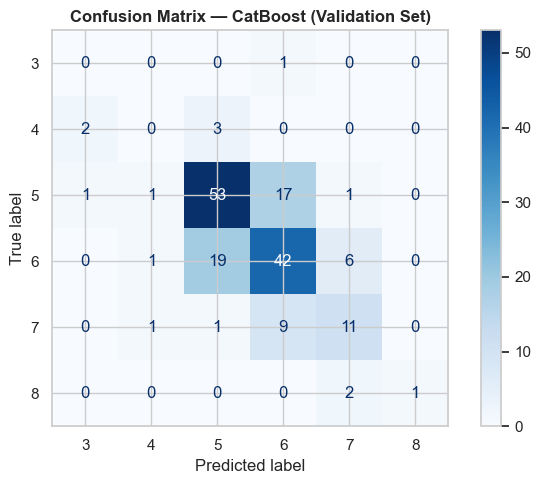

In [34]:
classes = sorted(set(y_val))
cm = confusion_matrix(y_val, val_pred, labels=classes)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Validation Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


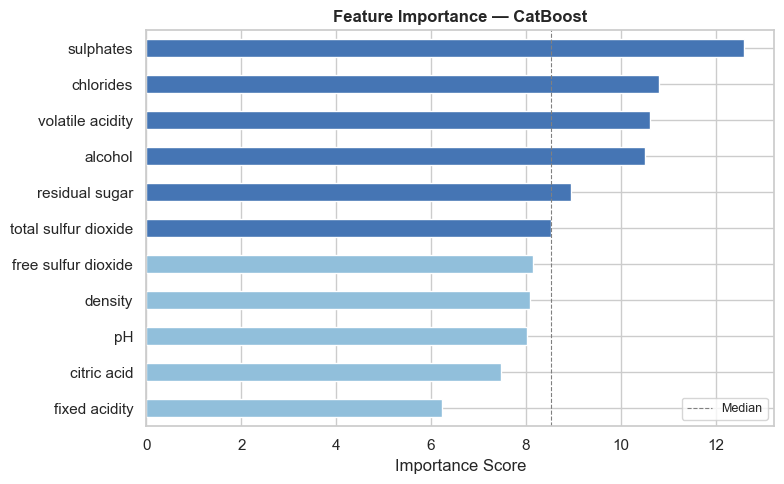

Feature Importance (descending):
sulphates              12.6028
chlorides              10.8036
volatile acidity       10.6230
alcohol                10.5190
residual sugar          8.9520
total sulfur dioxide    8.5285
free sulfur dioxide     8.1436
density                 8.0944
pH                      8.0272
citric acid             7.4697
fixed acidity           6.2361


In [35]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#4575b4' if v >= fi.median() else '#91bfdb' for v in fi.values]
    fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {best_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(fi.median(), color='gray', linestyle='--', linewidth=0.8, label='Median')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print('Feature Importance (descending):')
    print(fi.sort_values(ascending=False).round(4).to_string())
else:
    print(f'{best_name} tidak memiliki atribut feature_importances_.')

### 6.5 Prediksi & Export CSV

Model terbaik di-deploy pada data testing. Hasil prediksi (encoded 0–5) dikembalikan ke label
asli (3–8) menggunakan `le.inverse_transform()` sebelum disimpan ke file CSV.


In [36]:
pred_encoded = best_model.predict(X_test_sc)           # 0-5
y_pred_test  = le.inverse_transform(pred_encoded)       # 3-8

hasil_prediksi = pd.DataFrame({
    'Id'     : test_ids.values,
    'Quality': y_pred_test
})

print(f'Jumlah prediksi  : {len(hasil_prediksi)}')
print(f'Kelas yang muncul: {sorted(hasil_prediksi["Quality"].unique())}')
print()
print('Distribusi hasil prediksi:')
dist = hasil_prediksi['Quality'].value_counts().sort_index()
for k, v in dist.items():
    print(f'  Quality {k}: {v} sampel ({v/len(hasil_prediksi)*100:.1f}%)')
print()
print('Preview 10 baris pertama:')
print(hasil_prediksi.head(10).to_string(index=False))


Jumlah prediksi  : 286
Kelas yang muncul: [3, 4, 5, 6, 7, 8]

Distribusi hasil prediksi:
  Quality 3: 3 sampel (1.0%)
  Quality 4: 6 sampel (2.1%)
  Quality 5: 132 sampel (46.2%)
  Quality 6: 108 sampel (37.8%)
  Quality 7: 35 sampel (12.2%)
  Quality 8: 2 sampel (0.7%)

Preview 10 baris pertama:
  Id  Quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        6
 180        6
  82        5
 632        6
 592        5


In [37]:
output_path = 'hasilprediksi_008.csv'
hasil_prediksi.to_csv(output_path, sep=';', index=False)

print(f'File berhasil disimpan : {output_path}')
print(f'Format                 : separator=";", kolom=[Id, Quality]')

verify = pd.read_csv(output_path, sep=';')
print(f'Verifikasi baris       : {len(verify)} | Kolom: {verify.columns.tolist()}')
print()
print(verify.head(5).to_string(index=False))

File berhasil disimpan : hasilprediksi_008.csv
Format                 : separator=";", kolom=[Id, Quality]
Verifikasi baris       : 286 | Kolom: ['Id', 'Quality']

  Id  Quality
 222        5
1514        6
 417        5
 754        5
 516        5
